Task 1: Time Series Analysis with Linear Models
1. Data Exploration & Preprocessing

(308, 2)
Index(['observation_date', 'GDP'], dtype='object')


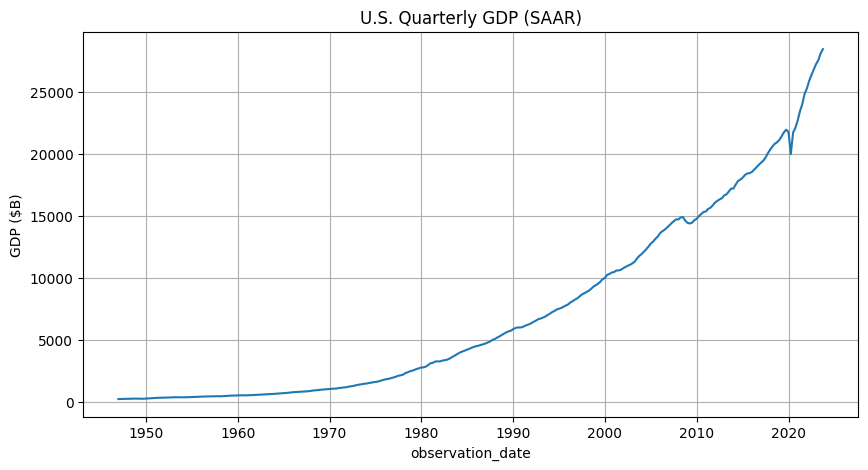

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#read csv file
file_path = "GDP.csv"
df = pd.read_csv(file_path)
print(df.shape)
print(df.columns)
df.head()

#datetime
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date")   #sort time
df = df.set_index("observation_date")

#plot
plt.figure(figsize=(10,5))
plt.plot(df.index,df["GDP"])
plt.title("U.S. Quarterly GDP (SAAR)")
plt.xlabel("observation_date")
plt.ylabel("GDP ($B)")
plt.grid(True)
plt.show()

2. Model Determination

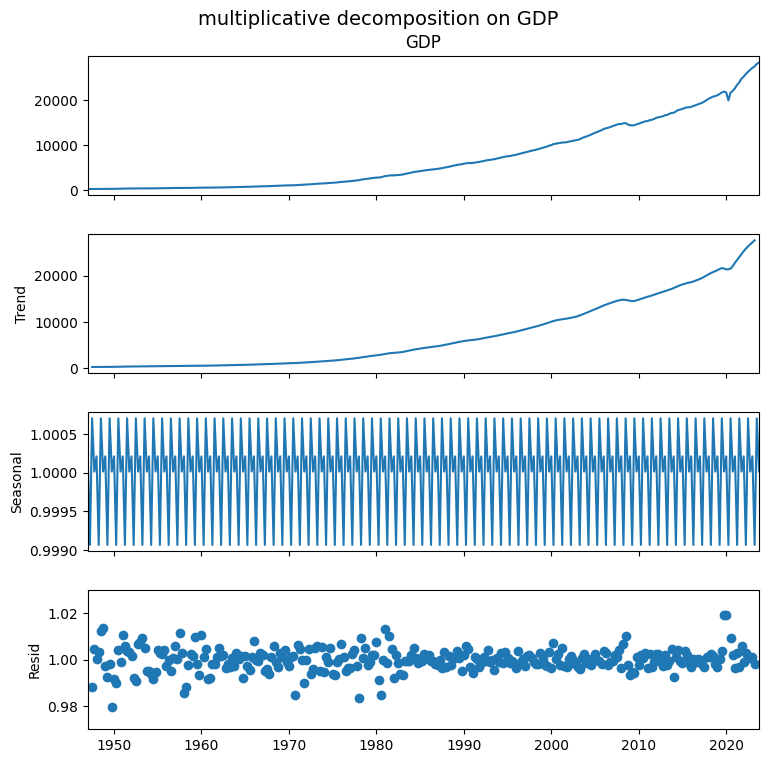

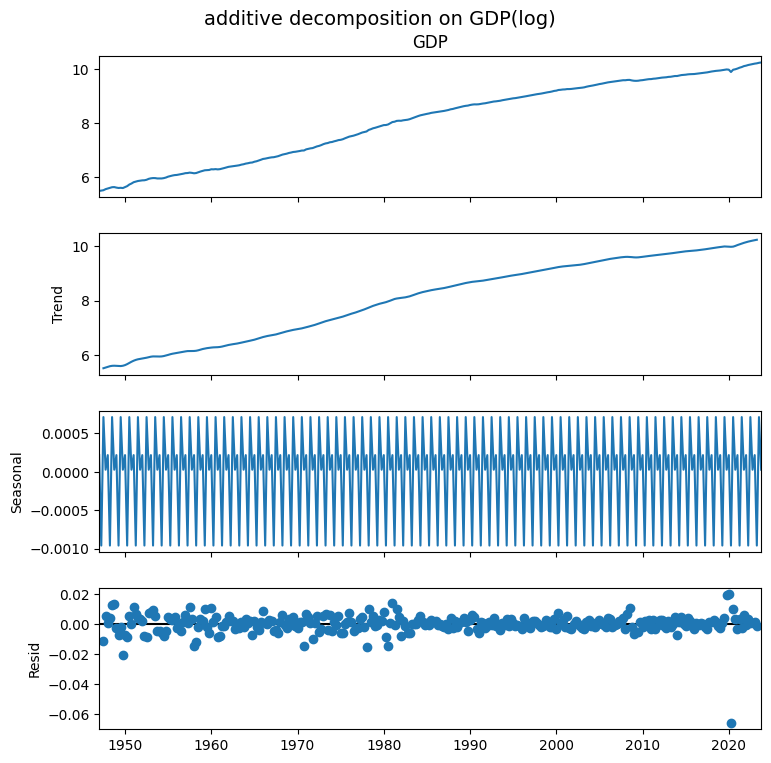

In [72]:
#Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

#seasonal
y = df["GDP"].copy() #avoid influencing original data
period =4
#multiplicative
decomp_mul = seasonal_decompose(y, model="multiplicative", period=period)
fig = decomp_mul.plot()
fig.set_size_inches(8,8)
plt.suptitle("multiplicative decomposition on GDP", fontsize=14)
plt.ylim(0.97, 1.03)
plt.show()
#additive
y_log = np.log(y)
decomp_add_log= seasonal_decompose(y_log, model="additive", period=period)
fig = decomp_add_log.plot()
fig.set_size_inches(8,8)
plt.suptitle("additive decomposition on GDP(log)", fontsize=14)
plt.show()

Apply a logarithmic transformation to stabilize the variance and convert the multiplicative relationship into an additive one. The residuals from the additive decomposition on the log-transformed GDP series exhibit more stable variance and are centered around zero, making them more suitable for linear time series modeling.

In [73]:
#test stationarity
from statsmodels.tsa.stattools import adfuller

#ADF test
result = adfuller(y_log)
print("ADF statistic",result[0])
print("p_value",result[1]) #answear shows p_value >0.05-----not statistic

#Difference d=1
y_log_diff = y_log.diff().dropna()
result_diff = adfuller(y_log_diff)
print("ADF statistic",result_diff[0])
print("p_value",result_diff[1])

ADF statistic -2.059645190196608
p_value 0.2610478602122786
ADF statistic -8.60930694915372
p_value 6.541308760978235e-14


The ADF test on the log-transformed series returned a p-value greater than 0.05, indicating that the series was still non-stationary.
After applying first-order differencing to the log series, the ADF test produced a p-value much smaller than 0.05. Therefore, I conclude that the differenced log series is stationary and set the differencing parameter d = 1.

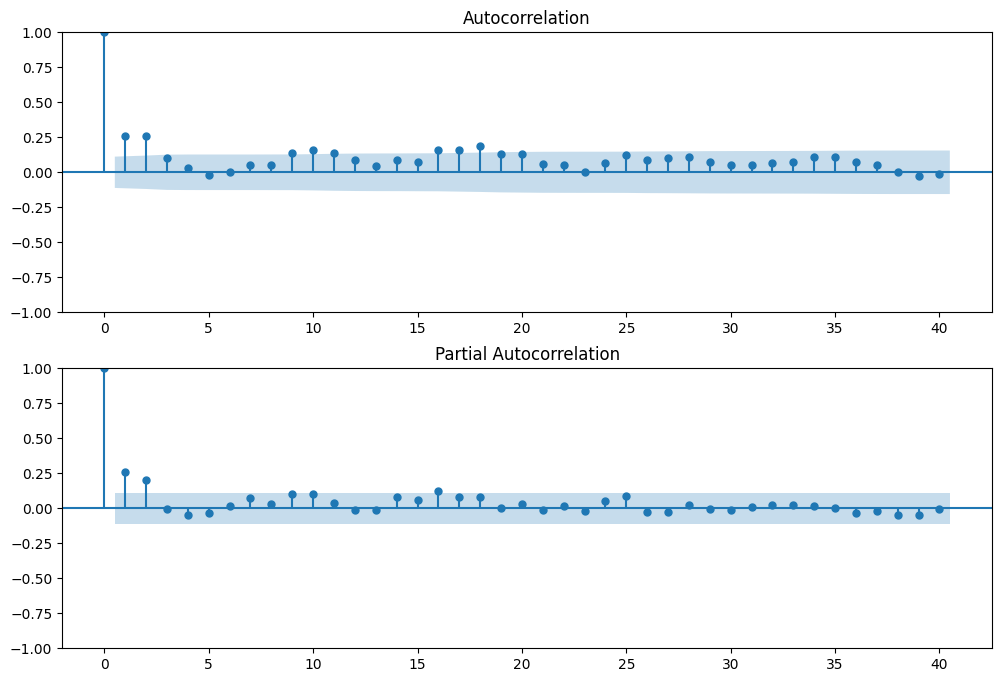

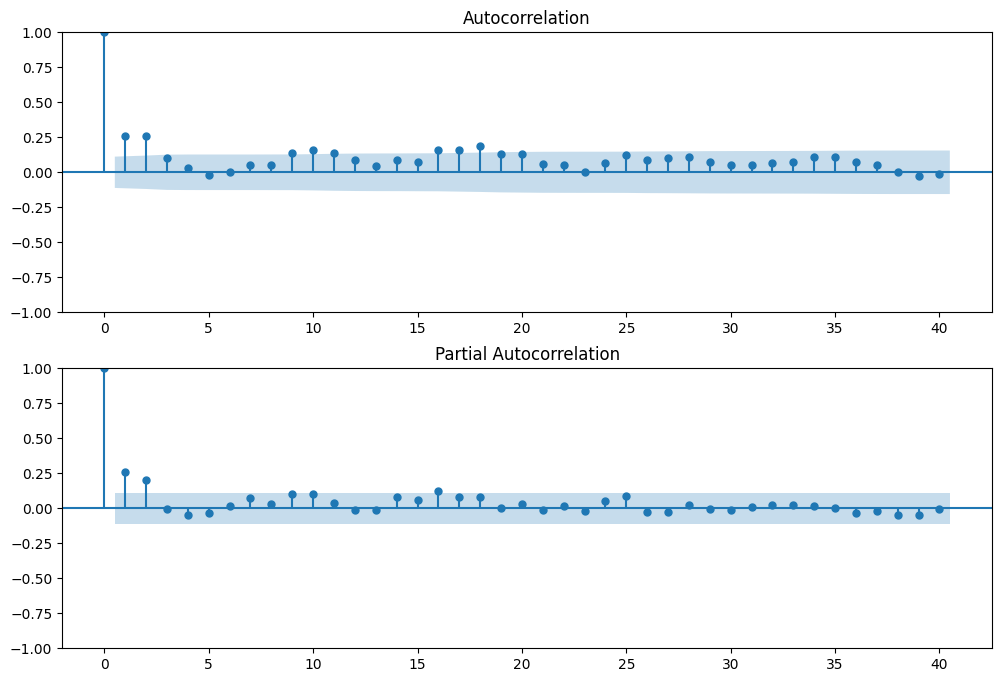

In [74]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_log_diff, lags=40, ax=axes[0])
plot_pacf(y_log_diff, lags=40, ax=axes[1])

In the ACF, only lags 1,2,3 are clearly significant; after that the correlations fall within the confidence band,
suggesting an MA component with q = 3.

In the PACF, lags 1,2, 3 are significant and the remaining lags are mostly within the confidence band, suggesting an
AR component with p = 3.

Therefore, I choose p = 3 and q = 3 (ARIMA(3,1,3)) as an initial specification based on the ACF/PACF patterns.

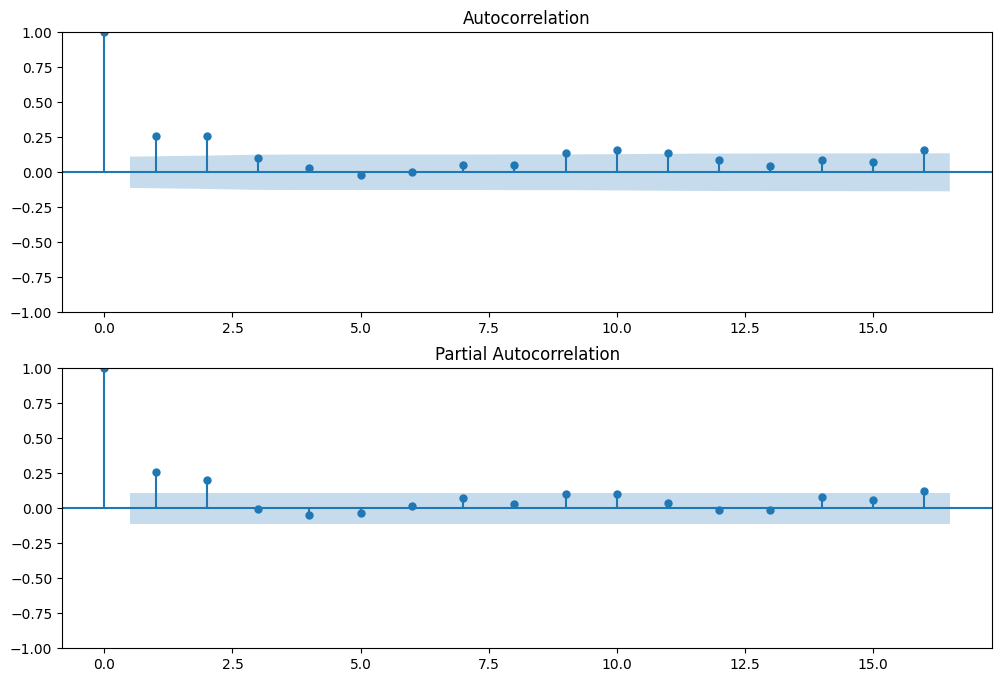

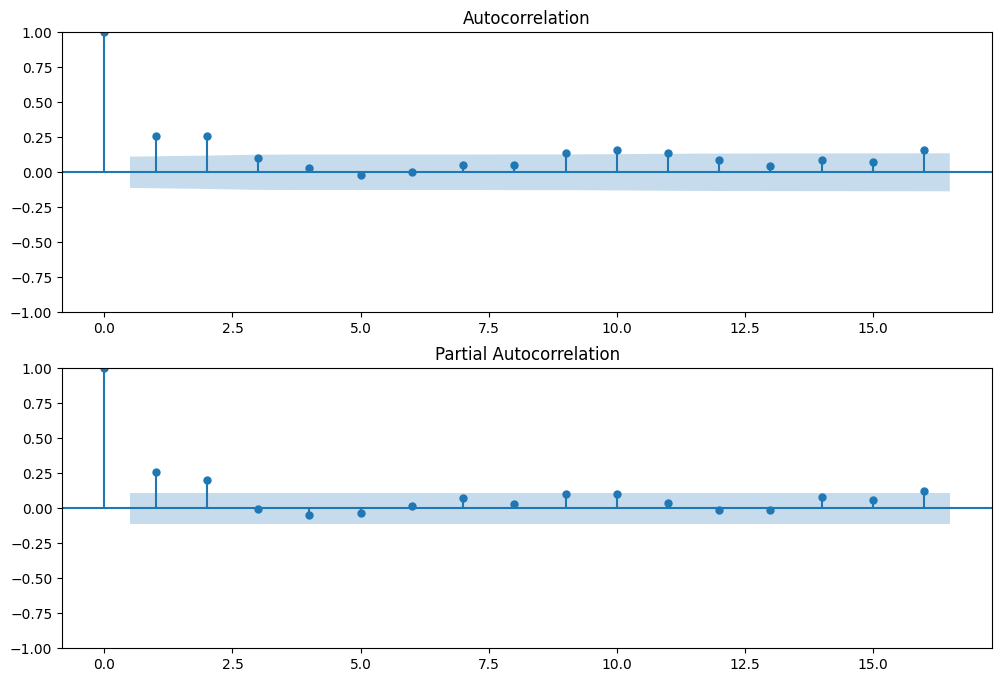

In [75]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_log_diff, lags=16, ax=axes[0])
plot_pacf(y_log_diff, lags=16, ax=axes[1])

After checking the ACF and PACF at seasonal lags (4, 8, 12)since the series is quarterly (s = 4). The spikes at lag
 are within the confidence bands in both ACF and PACF, indicating no clear seasonal component. Therefore, I do not
 include seasonal terms and set (P, D, Q, s) = (0, 0, 0, 4).

Model Justification:

Based on the time series analysis, I selected an ARIMA(3,1,3) model.

First, I applied a logarithmic transformation to stabilize the variance of the GDP series. The ADF test on the log-transformed data indicated non-stationarity (p-value > 0.05), so I performed first-order differencing. After differencing, the ADF test showed a very small p-value, confirming stationarity. Therefore, I set d = 1.

Next, I analyzed the ACF and PACF plots of the differenced log series. Both plots showed significant spikes up to lag 3 and fell within the confidence interval afterward, indicating AR and MA effects up to order 3. Hence, I selected p = 3 and q = 3.

Since no clear seasonal pattern was observed at seasonal lags, I did not include seasonal terms.

Thus, the final model chosen is ARIMA(3,1,3).

3.Model Training & Evaluation

In [76]:
#split train&test data
series = df["GDP"]
series = series.sort_index()
n = len(series)
split = int(n*0.8)
train = series.iloc[:split]
test = series.iloc[split:]

print(len(train), len(test))
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

246 62
1947-01-01 00:00:00 2008-04-01 00:00:00
2008-07-01 00:00:00 2023-10-01 00:00:00


In [77]:
y = df["GDP"]
y_log = np.log(y)
z = y_log.diff().dropna()

n = len(z)
split = int(0.8 * n)
train = z.iloc[:split]
test  = z.iloc[split:]
z =train.values.astype(float)

#arma_residuals
def arma_residuals( z, phi, theta, p =3 , q =3):
    z = np.asarray(z,dtype=float)
    n = len(z)
    eps = np.zeros(n,dtype=float)
    for t in range(max(p,q),n):
        ar_part = 0.0
        for i in range(1,p+1):
            ar_part += phi[i-1]*z[t-i]
        ma_part = 0.0
        for i in range(1,q+1):
            ma_part += theta[i-1]*eps[t-i]
        eps[t] = z[t] - ar_part - ma_part
    return eps

#minimize SSE
def sse_loss(z, phi, theta, p= 3, q=3 ):
    eps = arma_residuals(z, phi, theta, p, q)
    start = max(p,q)
    return np.sum(eps[start:]**2)

#initialize parameters
def init_ar3_ols(z,p=3):
    z = np.asarray(z,dtype=float)
    n = len(z)
    y = z[p:]
    X =np.column_stack([z[p-1:-1], z[p-2:-2], z[p-3:-3]]) #z[p-1:-1]----zt-1, z[p-2:-2]----zt-2, z[p-3:-3]----zt-3
    phi = np.linalg.lstsq(X, y, rcond=None)[0]   #solve the least square problem
    return phi
phi0 = init_ar3_ols(z, p=3) #get the primary phi0
theta0 = np.zeros(3)  #MA parameters begin with zero

#numerical gradient
def numerical_grad(z, phi, theta, h=1e-5):
    base = sse_loss(z, phi, theta)
    g_phi = np.zeros_like(phi)
    g_theta = np.zeros_like(theta)

    for i in range(len(phi)):
        phi2 = phi.copy()
        phi2[i] += h
        g_phi[i] = (sse_loss(z, phi2, theta) - base) / h

    for j in range(len(theta)):
        th2 = theta.copy()
        th2[j] += h
        g_theta[j] = (sse_loss(z, phi, th2) - base) / h

    return g_phi, g_theta

#training loop
def fit_arma33(z, iters=300, lr=1e-4, clip=5.0):
    phi = init_ar3_ols(z, p=3)
    theta = np.zeros(3, dtype=float)

    best_phi = phi.copy()
    best_theta = theta.copy()
    best_loss = sse_loss(z, phi, theta)

    for t in range(iters):
        g_phi, g_theta = numerical_grad(z, phi, theta)

        # gradient clip
        g_phi = np.clip(g_phi, -clip, clip)
        g_theta = np.clip(g_theta, -clip, clip)

        phi = phi - lr * g_phi
        theta = theta - lr * g_theta

        cur = sse_loss(z, phi, theta)
        if cur < best_loss:
            best_loss = cur
            best_phi = phi.copy()
            best_theta = theta.copy()

        if (t+1) % 25 == 0:
            print(f"iter {t+1:4d} | loss={cur:.4e} | best={best_loss:.4e}")

    return best_phi, best_theta, best_loss

phi_hat, theta_hat, train_loss = fit_arma33(z, iters=300, lr=1e-4)
print("phi_hat:", phi_hat)
print("theta_hat:", theta_hat)

iter   25 | loss=2.5259e-02 | best=2.5259e-02
iter   50 | loss=2.5259e-02 | best=2.5259e-02
iter   75 | loss=2.5259e-02 | best=2.5259e-02
iter  100 | loss=2.5259e-02 | best=2.5259e-02
iter  125 | loss=2.5259e-02 | best=2.5259e-02
iter  150 | loss=2.5258e-02 | best=2.5258e-02
iter  175 | loss=2.5258e-02 | best=2.5258e-02
iter  200 | loss=2.5258e-02 | best=2.5258e-02
iter  225 | loss=2.5258e-02 | best=2.5258e-02
iter  250 | loss=2.5258e-02 | best=2.5258e-02
iter  275 | loss=2.5258e-02 | best=2.5258e-02
iter  300 | loss=2.5258e-02 | best=2.5258e-02
phi_hat: [ 0.55947811  0.34776032 -0.02323006]
theta_hat: [ 1.16288374e-05 -5.92392421e-05 -1.61979940e-04]


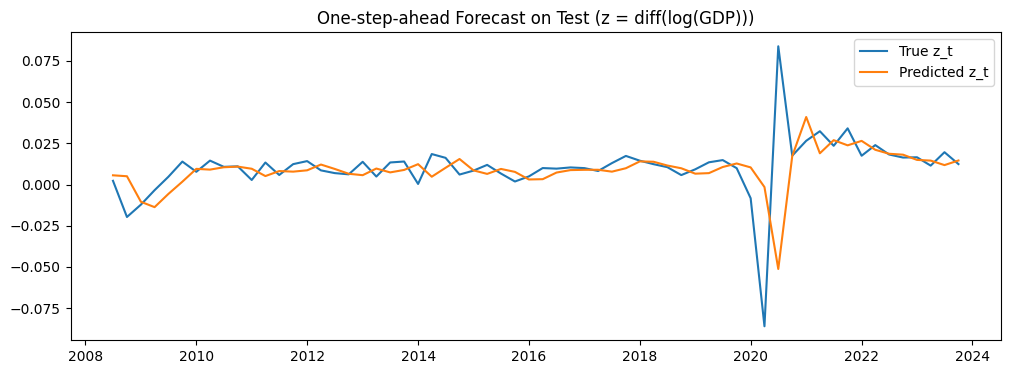

In [78]:
z_all = np.concatenate([train.values.astype(float), test.values.astype(float)])
n_train = len(train)
n_test = len(test)

eps_all = arma_residuals(z_all, phi_hat, theta_hat, p=3, q=3)

p = q = 3
z_pred_test = np.zeros(n_test, dtype=float)

for t in range(n_train, n_train + n_test):
    # 1-step forecast using past z and past eps
    ar_part = 0.0
    for i in range(1, p+1):
        ar_part += phi_hat[i-1] * z_all[t-i]

    ma_part = 0.0
    for j in range(1, q+1):
        ma_part += theta_hat[j-1] * eps_all[t-j]

    z_hat = ar_part + ma_part
    z_pred_test[t - n_train] = z_hat

    # update eps at time t using the realized test value
    eps_all[t] = z_all[t] - z_hat

    import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True z_t")
plt.plot(test.index, z_pred_test, label="Predicted z_t")
plt.legend()
plt.title("One-step-ahead Forecast on Test (z = diff(log(GDP)))")
plt.show()

In [79]:
log_pred_test = np.zeros_like(z_pred_test)

for i in range(len(z_pred_test)):
    idx = split + i   # original series
    log_prev_real = y_log.iloc[idx - 1]
    log_pred_test[i] = log_prev_real + z_pred_test[i]

    gdp_pred_test = np.exp(log_pred_test)
    gdp_test_real = df.loc[test.index, "GDP"].values
#RMSE
rmse = np.sqrt(np.mean((gdp_test_real - gdp_pred_test)**2))

#MAE
mae = np.mean(np.abs(gdp_test_real - gdp_pred_test))

#MAPE
mape = np.mean(np.abs((gdp_test_real - gdp_pred_test) / gdp_test_real)) * 100
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape, "%")


RMSE: 483.5725925444175
MAE : 335.93010989205357
MAPE: 1.6426174255345025 %


Interpretation of Evaluation Metrics

The RMSE is approximately 483, which means that the typical magnitude of prediction errors is about 483 billion dollars in absolute scale. Since U.S. GDP in the test period is around 20,000–30,000 billion dollars, this error is relatively small compared to the overall level.

The MAE is approximately 335, indicating that on average, the model's forecast deviates from the true GDP by about 335 billion dollars per quarter. MAE is less sensitive to extreme shocks than RMSE, so it reflects the typical forecasting accuracy more directly.

The MAPE is about 1.64%, meaning that the average percentage error is only around 1.6% of the true GDP value. This indicates that the model provides highly accurate forecasts in relative terms.

Overall, all three metrics suggest that the ARIMA model captures the main dynamics of GDP and achieves strong forecasting performance on the test set.

4.Comparative Analysis

In [80]:
# Model 2: AR(3) on z = diff(log(GDP))

def fit_ar3_ols(z_train_series):
    z_arr = z_train_series.values.astype(float)
    p = 3

    y = z_arr[p:]  # z_t
    X = np.column_stack([
        z_arr[p-1:-1],  # z_{t-1}
        z_arr[p-2:-2],  # z_{t-2}
        z_arr[p-3:-3],  # z_{t-3}
    ])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]  # [phi1, phi2, phi3]
    return beta

phi_ar3 = fit_ar3_ols(train)
print("Model2 AR(3) phi:", phi_ar3)

Model2 AR(3) phi: [ 0.55947803  0.34776021 -0.0232302 ]


In [81]:
#Rolling one-step forecast------z_pred_test（AR(3)）
def forecast_ar3_one_step(train_series, test_series, phi_ar3):
    p = 3
    z_hist = train_series.values.astype(float).tolist()
    z_test = test_series.values.astype(float)

    z_pred = np.zeros(len(z_test), dtype=float)

    for i in range(len(z_test)):
        # latest 3:z_{t-1}, z_{t-2}, z_{t-3}
        z_t1 = z_hist[-1]
        z_t2 = z_hist[-2]
        z_t3 = z_hist[-3]

        z_hat = phi_ar3[0]*z_t1 + phi_ar3[1]*z_t2 + phi_ar3[2]*z_t3
        z_pred[i] = z_hat

        # rolling
        z_hist.append(float(z_test[i]))

    return z_pred

z_pred_test_m2 = forecast_ar3_one_step(train, test, phi_ar3)

In [82]:
#z_pred---->GDP_pred and calculate RMSE, MAE, MAPE

#log(GDP)_pred[t] = log(GDP)_{t-1}^{real} + z_pred[t]
log_pred_test_m2 = np.zeros_like(z_pred_test_m2, dtype=float)

for i, tstamp in enumerate(test.index):
    pos = y_log.index.get_loc(tstamp)         #the location of the timestamp in y_log
    log_prev_real = y_log.iloc[pos - 1]     #last real log(GDP)
    log_pred_test_m2[i] = log_prev_real + z_pred_test_m2[i]

#log(GDP)_pred[t] = exp(log(GDP)_pred[t]) = GDP_{t}
gdp_pred_test_m2 = np.exp(log_pred_test_m2)

#GDP_real = df.loc[test.index, "GDP"].values.astype(float)
gdp_test_real = df.loc[test.index, "GDP"].values.astype(float)

#metrics（from scratch）
rmse_m2 = np.sqrt(np.mean((gdp_test_real - gdp_pred_test_m2)**2))
mae_m2  = np.mean(np.abs(gdp_test_real - gdp_pred_test_m2))
mape_m2 = np.mean(np.abs((gdp_test_real - gdp_pred_test_m2) / gdp_test_real)) * 100

print("Model2 (AR(3)) RMSE:", rmse_m2)
print("Model2 (AR(3)) MAE :", mae_m2)
print("Model2 (AR(3)) MAPE:", mape_m2, "%")

Model2 (AR(3)) RMSE: 435.48387424527766
Model2 (AR(3)) MAE : 171.60583644955253
Model2 (AR(3)) MAPE: 0.8679708841223139 %


In [83]:
#COMPARE
print("\n===== Comparison on Test (GDP scale) =====")
print("Model1 (ARMA(3,3)):")
print("  RMSE:", rmse)
print("  MAE :", mae)
print("  MAPE:", mape, "%")

print("\nModel2 (AR(3)):")
print("  RMSE:", rmse_m2)
print("  MAE :", mae_m2)
print("  MAPE:", mape_m2, "%")


===== Comparison on Test (GDP scale) =====
Model1 (ARMA(3,3)):
  RMSE: 483.5725925444175
  MAE : 335.93010989205357
  MAPE: 1.6426174255345025 %

Model2 (AR(3)):
  RMSE: 435.48387424527766
  MAE : 171.60583644955253
  MAPE: 0.8679708841223139 %


Strengths and Weaknesses Comparison:

Model 1 (ARMA(3,3)) is more flexible because it incorporates both autoregressive and moving-average components. This
allows the model to capture more complex temporal dynamics and residual shock propagation. However, it has more
parameters and requires iterative optimization, which increases the risk of overfitting and estimation instability.

Model 2 (AR(3)) is simpler and more parsimonious. It only models autoregressive dependence and can be estimated directly
using ordinary least squares. This makes the model more stable and computationally efficient. Although it may lack
flexibility compared to ARMA, its simplicity often leads to better out-of-sample generalization.

Based on the evaluation metrics, Model 2 achieves lower RMSE, MAE, and MAPE, indicating superior forecasting performance
on the test set.

Task 2: Stationarity of Autoregressive Models

Part 1 – Simple Case (2 points): Prove this property for a first-order autoregressive
model, AR(1).

### Stationarity Condition for AR(1)

Consider the AR(1) process:

$$
X_t = \phi X_{t-1} + \varepsilon_t,
$$

where $\varepsilon_t$ is white noise with mean 0 and variance $\sigma^2$.

By recursive substitution:

$$
X_t = \phi(\phi X_{t-2} + \varepsilon_{t-1}) + \varepsilon_t
$$

$$
= \phi^2 X_{t-2} + \phi \varepsilon_{t-1} + \varepsilon_t
$$

Continuing recursively:

$$
X_t = \phi^k X_{t-k} + \sum_{i=0}^{k-1} \phi^i \varepsilon_{t-i}
$$

For the process to be stationary, the term $\phi^k X_{t-k}$ must vanish as $k \to \infty$.

This requires:

$$
|\phi| < 1
$$

Therefore, the AR(1) process is stationary if and only if:

$$
|\phi| < 1.
$$

### Stationarity Condition for AR(p)

Consider the AR(p) model:

$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t.
$$

Using the lag operator $L$, where $L X_t = X_{t-1}$, the model can be written as:

$$
(1 - \phi_1 L - \phi_2 L^2 - \cdots - \phi_p L^p) X_t = \varepsilon_t.
$$

Define the characteristic polynomial:

$$
\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p.
$$

The AR(p) process is stationary if all roots of the equation

$$
\Phi(z) = 0
$$

lie outside the unit circle, i.e.,

$$
|z| > 1.
$$

This condition ensures that the effect of past shocks decays over time.

Task 3: Principal Component Analysis Implementation

1.Implementation

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# read red / white
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

# data centering
df = pd.concat([red, white], ignore_index=True)

print("Shape:", df.shape)
print(df.head())

# y = quality score
y = df["quality"].values

# X = all physical features
X = df.drop(columns=["quality"]).values

print("X shape:", X.shape)
print("y shape:", y.shape)

# standardization
def standardize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0, ddof=1)
    sigma[sigma == 0] = 1
    X_std = (X - mu) / sigma
    return X_std, mu, sigma

X_std, mu, sigma = standardize(X)

print("Mean (first 5 features):", np.mean(X_std, axis=0)[:5])
print("Std  (first 5 features):", np.std(X_std, axis=0, ddof=1)[:5])

Shape: (6497, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2 

In [85]:
# Covariance matrix computation
def covariance_matrix(X_std):
    n = X_std.shape[0]
    C = (X_std.T @ X_std) / (n - 1)
    return C

C = covariance_matrix(X_std)
print("Covariance matrix shape:", C.shape)

Covariance matrix shape: (11, 11)


In [86]:
# Eigenvalue/eigenvector calculation
def eig_decomposition(C):
    eigvals, eigvecs = np.linalg.eigh(C)
    return eigvals, eigvecs

eigvals, eigvecs = eig_decomposition(C)

print("Eigenvalues shape:", eigvals.shape)
print("Eigenvectors shape:", eigvecs.shape)

Eigenvalues shape: (11,)
Eigenvectors shape: (11, 11)


In [87]:
# Projection of data onto principal components

idx = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[idx]
eigvecs_sorted = eigvecs[:, idx]

print("Top 5 eigenvalues:", eigvals_sorted[:5])

Top 5 eigenvalues: [3.02986865 2.49382603 1.55634695 0.97055208 0.71987492]


In [88]:
# Variance explained calculation
def explained_variance(eigvals_sorted):
    total = np.sum(eigvals_sorted)
    ratio = eigvals_sorted / total
    cum_ratio = np.cumsum(ratio)
    return ratio, cum_ratio

evr, cum_evr = explained_variance(eigvals_sorted)

print("Top 5 explained variance ratio:", evr[:5])
print("Cumulative explained variance (first 5):", cum_evr[:5])

Top 5 explained variance ratio: [0.2754426  0.22671146 0.14148609 0.08823201 0.06544317]
Cumulative explained variance (first 5): [0.2754426  0.50215406 0.64364015 0.73187216 0.79731533]


2.Visualization & Analysis

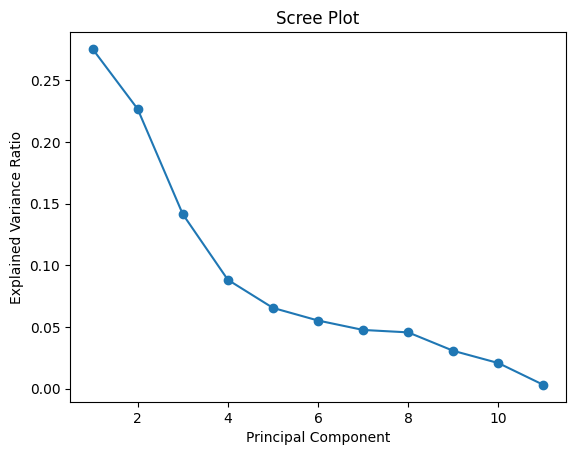

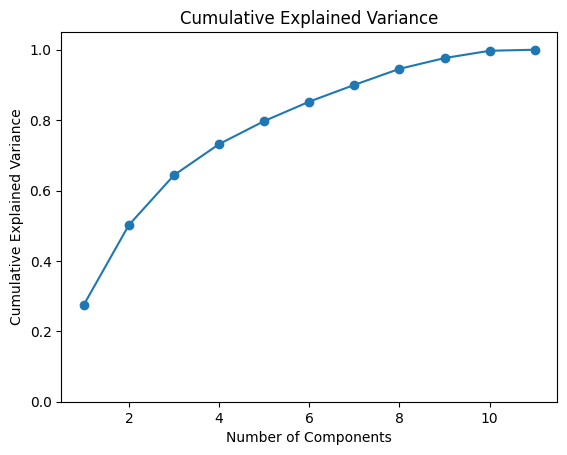

k for 90% variance: 7  (cum= 0.9000853725053393 )
k for 95% variance: 9  (cum= 0.9763157666625489 )


In [89]:
# Scree plot: explained variance ratio for each PC
pcs = np.arange(1, len(evr) + 1)

plt.figure()
plt.plot(pcs, evr, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

# Cumulative explained variance
plt.figure()
plt.plot(pcs, cum_evr, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.show()

# aotu-determined k
k90 = int(np.argmax(cum_evr >= 0.90) + 1)
k95 = int(np.argmax(cum_evr >= 0.95) + 1)

print("k for 90% variance:", k90, " (cum=", cum_evr[k90-1], ")")
print("k for 95% variance:", k95, " (cum=", cum_evr[k95-1], ")")

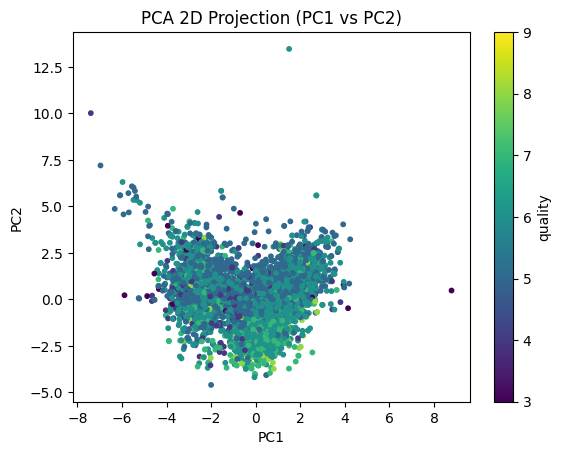

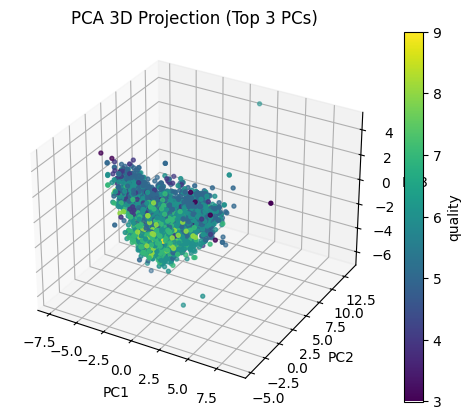

In [90]:
# Visualize data in 2D and 3D using the top principal components

# Project to 2D
k = 2
W2 = eigvecs_sorted[:, :k]
Z2 = X_std @ W2

plt.figure()
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=y, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection (PC1 vs PC2)")
plt.colorbar(sc, label="quality")
plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Project to 3D
k = 3
W3 = eigvecs_sorted[:, :k]
Z3 = X_std @ W3

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=y, s=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D Projection (Top 3 PCs)")
fig.colorbar(p, ax=ax, label="quality")
plt.show()

3.parameter analysis

Class distribution:
[2384 4113]
k= 1, accuracy=0.6931, cumulative variance=0.2754
k= 2, accuracy=0.6815, cumulative variance=0.5022
k= 3, accuracy=0.6885, cumulative variance=0.6436
k= 4, accuracy=0.6854, cumulative variance=0.7319
k= 5, accuracy=0.7008, cumulative variance=0.7973
k= 6, accuracy=0.7015, cumulative variance=0.8525
k= 7, accuracy=0.7069, cumulative variance=0.9001
k= 8, accuracy=0.7177, cumulative variance=0.9457
k= 9, accuracy=0.7638, cumulative variance=0.9763
k=10, accuracy=0.7638, cumulative variance=0.9970
k=11, accuracy=0.7615, cumulative variance=1.0000


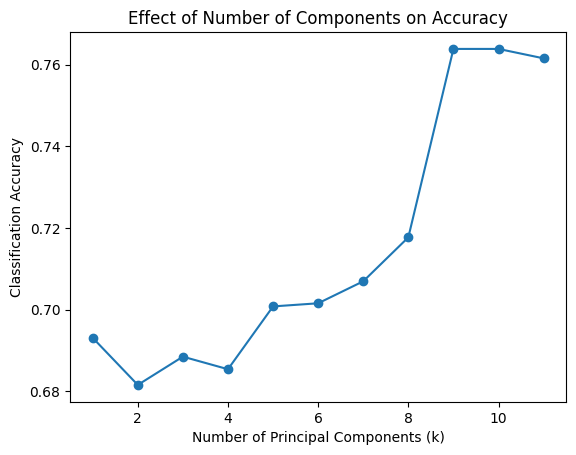

In [91]:
# change quality score to binary
y_binary = (y >= 6).astype(int)

print("Class distribution:")
print(np.bincount(y_binary))

# logistic regression
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_train(X, y, lr=0.1, iters=2000):
    # X: (n, d), y: (n,)
    n, d = X.shape
    w = np.zeros(d, dtype=float)
    b = 0.0

    for _ in range(iters):
        z = X @ w + b
        p = sigmoid(z)

        # gradients
        dw = (X.T @ (p - y)) / n
        db = np.sum(p - y) / n

        # update
        w -= lr * dw
        b -= lr * db

    return w, b

def logistic_predict(X, w, b):
    p = sigmoid(X @ w + b)
    return (p >= 0.5).astype(int)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def evaluate_model(Z, y, test_size=0.2):
    # manual split
    n = len(y)
    split = int(n * (1 - test_size))

    X_train = Z[:split].astype(float)
    X_test  = Z[split:].astype(float)
    y_train = y[:split].astype(int)
    y_test  = y[split:].astype(int)

    w, b = logistic_train(X_train, y_train, lr=0.1, iters=2000)
    y_pred = logistic_predict(X_test, w, b)
    return accuracy(y_test, y_pred)

# test different k
ks = range(1, X.shape[1] + 1)
accuracies = []

for k in ks:
    Wk = eigvecs_sorted[:, :k]
    Zk = X_std @ Wk
    acc = evaluate_model(Zk, y_binary)
    accuracies.append(acc)
    print(f"k={k:2d}, accuracy={acc:.4f}, cumulative variance={cum_evr[k-1]:.4f}")

plt.figure()
plt.plot(ks, accuracies, marker='o')
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Classification Accuracy")
plt.title("Effect of Number of Components on Accuracy")
plt.show()

#Effect of Number of Principal Components on Downstream Classification Performance

The classification accuracy generally increases as the number of principal components increases.

When only a small number of components (k=1 to 4) are used, the model achieves relatively low accuracy (around 0.68–0.69). This suggests that the first few principal components, although capturing large variance, do not fully preserve the discriminative information needed for classification.

As k increases, accuracy steadily improves. The performance reaches its maximum around k=9 or k=10 (approximately 0.764), where the cumulative explained variance is above 97%. This indicates that most useful information for classification is retained once a sufficient number of components is included.

When all components are used (k=11), the accuracy slightly decreases. This may be due to the inclusion of low-variance components that mainly capture noise rather than meaningful signal.

Overall, the results suggest that selecting an intermediate number of principal components (around 9–10) provides a good trade-off between dimensionality reduction and predictive performance.